# 📊 SKU-110K Dataset Exploration

**Project:** Stock Opname Monitoring dengan Deep Learning  
**Author:** Ivan David (B25B8M113)  
**Dataset:** SKU-110K - Dense Object Detection in Retail Environments

---

## 🎯 Tujuan Notebook:
1. Load dan eksplorasi SKU-110K dataset
2. Visualisasi sample images dengan bounding boxes
3. Analisis distribusi data
4. Persiapan data untuk training

## 1. Import Libraries

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


## 2. Dataset Configuration

In [3]:
# Path configuration
BASE_DIR = "./data"
IMAGES_DIR = os.path.join(BASE_DIR, "images")
ANNOTATIONS_DIR = os.path.join(BASE_DIR, "annotations")

# Check if dataset exists
if not os.path.exists(BASE_DIR):
    print("⚠️ Dataset tidak ditemukan!")
    print(f"Pastikan dataset ada di: {BASE_DIR}")
    print("Jalankan: python setup_dataset.py")
else:
    print("✓ Dataset ditemukan!")
    print(f"📁 Base directory: {BASE_DIR}")

# Check dataset structure
ORGANIZED_STRUCTURE = os.path.exists(os.path.join(IMAGES_DIR, "train"))

if ORGANIZED_STRUCTURE:
    print("📂 Struktur: Organized (train/val/test folders)")
    TRAIN_IMG_DIR = os.path.join(IMAGES_DIR, "train")
    VAL_IMG_DIR = os.path.join(IMAGES_DIR, "val")
    TEST_IMG_DIR = os.path.join(IMAGES_DIR, "test")
else:
    print("📂 Struktur: Flat (semua images dalam 1 folder)")
    print("💡 Tip: Jalankan 'python reorganize_dataset.py' untuk organize")
    TRAIN_IMG_DIR = IMAGES_DIR
    VAL_IMG_DIR = IMAGES_DIR
    TEST_IMG_DIR = IMAGES_DIR

✓ Dataset ditemukan!
📁 Base directory: ./data
📂 Struktur: Flat (semua images dalam 1 folder)
💡 Tip: Jalankan 'python reorganize_dataset.py' untuk organize


## 3. Load Annotations

In [10]:
def load_annotations(split='train'):
    """Load annotations untuk train/val/test split"""
    ann_file = os.path.join(ANNOTATIONS_DIR, f"annotations_{split}.csv")
    
    if not os.path.exists(ann_file):
        print(f"⚠️ File tidak ditemukan: {ann_file}")
        return None
    
    # Read CSV tanpa header, lalu assign column names
    df = pd.read_csv(ann_file, header=None)
    
    # Assign column names
    df.columns = ['image_name', 'x1', 'y1', 'x2', 'y2', 'class', 'image_width', 'image_height']
    
    print(f"✓ Loaded {split} annotations: {len(df)} rows")
    return df

# Load semua splits
train_df = load_annotations('train')
val_df = load_annotations('val')
test_df = load_annotations('test')

# Display info
if train_df is not None:
    print("\n📊 Dataset Split:")
    print(f"  • Train: {len(train_df)} annotations")
    print(f"  • Val: {len(val_df)} annotations")
    print(f"  • Test: {len(test_df)} annotations")
    
    print("\n✓ Columns sekarang:")
    print(train_df.columns.tolist())
    
    print("\n✓ Sample data:")
    print(train_df.head())

✓ Loaded train annotations: 1208482 rows
✓ Loaded val annotations: 90968 rows
✓ Loaded test annotations: 431546 rows

📊 Dataset Split:
  • Train: 1208482 annotations
  • Val: 90968 annotations
  • Test: 431546 annotations

✓ Columns sekarang:
['image_name', 'x1', 'y1', 'x2', 'y2', 'class', 'image_width', 'image_height']

✓ Sample data:
    image_name    x1    y1    x2    y2   class  image_width  image_height
0  train_0.jpg   208   537   422   814  object         3024          3024
1  train_0.jpg  1268  1923  1365  2209  object         3024          3024
2  train_0.jpg  1135  2074  1261  2166  object         3024          3024
3  train_0.jpg  1045  2085  1122  2258  object         3024          3024
4  train_0.jpg   976  2036  1040  2177  object         3024          3024


## 4. Explore Annotations Structure

In [11]:
# Check columns
print("📋 Columns in annotations:")
print(train_df.columns.tolist())

print("\n🔍 First 5 rows:")
train_df.head()

📋 Columns in annotations:
['image_name', 'x1', 'y1', 'x2', 'y2', 'class', 'image_width', 'image_height']

🔍 First 5 rows:


,image_name,x1,y1,x2,y2,class,image_width,image_height
0,train_0.jpg,208,537,422,814,object,3024,3024
1,train_0.jpg,1268,1923,1365,2209,object,3024,3024
2,train_0.jpg,1135,2074,1261,2166,object,3024,3024
3,train_0.jpg,1045,2085,1122,2258,object,3024,3024
4,train_0.jpg,976,2036,1040,2177,object,3024,3024


In [12]:
# Info tentang dataset
print("ℹ️ Dataset Info:")
train_df.info()

ℹ️ Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1208482 entries, 0 to 1208481
Data columns (total 8 columns):
 #   Column        Non-Null Count    Dtype 
---  ------        --------------    ----- 
 0   image_name    1208482 non-null  object
 1   x1            1208482 non-null  int64 
 2   y1            1208482 non-null  int64 
 3   x2            1208482 non-null  int64 
 4   y2            1208482 non-null  int64 
 5   class         1208482 non-null  object
 6   image_width   1208482 non-null  int64 
 7   image_height  1208482 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 73.8+ MB


## 5. Analisis Distribusi Data

In [13]:
# Jumlah objek per image
objects_per_image = train_df.groupby('image_name').size().reset_index(name='count')

print("📊 Statistik Objek per Image:")
print(f"  • Mean: {objects_per_image['count'].mean():.2f}")
print(f"  • Median: {objects_per_image['count'].median():.2f}")
print(f"  • Min: {objects_per_image['count'].min()}")
print(f"  • Max: {objects_per_image['count'].max()}")
print(f"  • Total unique images: {len(objects_per_image)}")

📊 Statistik Objek per Image:
  • Mean: 147.04
  • Median: 138.00
  • Min: 1
  • Max: 576
  • Total unique images: 8219


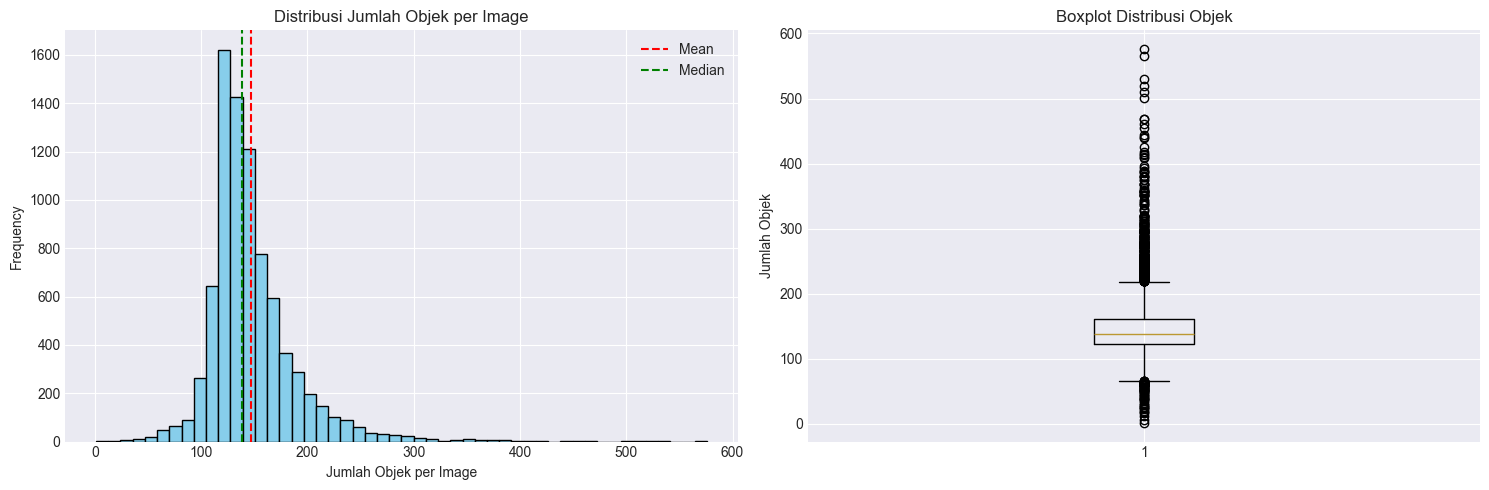

In [14]:
# Visualisasi distribusi
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(objects_per_image['count'], bins=50, color='skyblue', edgecolor='black')
axes[0].set_xlabel('Jumlah Objek per Image')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribusi Jumlah Objek per Image')
axes[0].axvline(objects_per_image['count'].mean(), color='red', linestyle='--', label='Mean')
axes[0].axvline(objects_per_image['count'].median(), color='green', linestyle='--', label='Median')
axes[0].legend()

# Boxplot
axes[1].boxplot(objects_per_image['count'])
axes[1].set_ylabel('Jumlah Objek')
axes[1].set_title('Boxplot Distribusi Objek')

plt.tight_layout()
plt.show()

## 6. Analisis Bounding Box

In [15]:
# Hitung ukuran bounding box
train_df['bbox_width'] = train_df['x2'] - train_df['x1']
train_df['bbox_height'] = train_df['y2'] - train_df['y1']
train_df['bbox_area'] = train_df['bbox_width'] * train_df['bbox_height']

print("📏 Statistik Bounding Box:")
print(f"\nWidth:")
print(f"  • Mean: {train_df['bbox_width'].mean():.2f}")
print(f"  • Median: {train_df['bbox_width'].median():.2f}")
print(f"\nHeight:")
print(f"  • Mean: {train_df['bbox_height'].mean():.2f}")
print(f"  • Median: {train_df['bbox_height'].median():.2f}")
print(f"\nArea:")
print(f"  • Mean: {train_df['bbox_area'].mean():.2f}")
print(f"  • Median: {train_df['bbox_area'].median():.2f}")

📏 Statistik Bounding Box:

Width:
  • Mean: 120.81
  • Median: 103.00

Height:
  • Mean: 190.11
  • Median: 181.00

Area:
  • Mean: 22196.18
  • Median: 18328.00


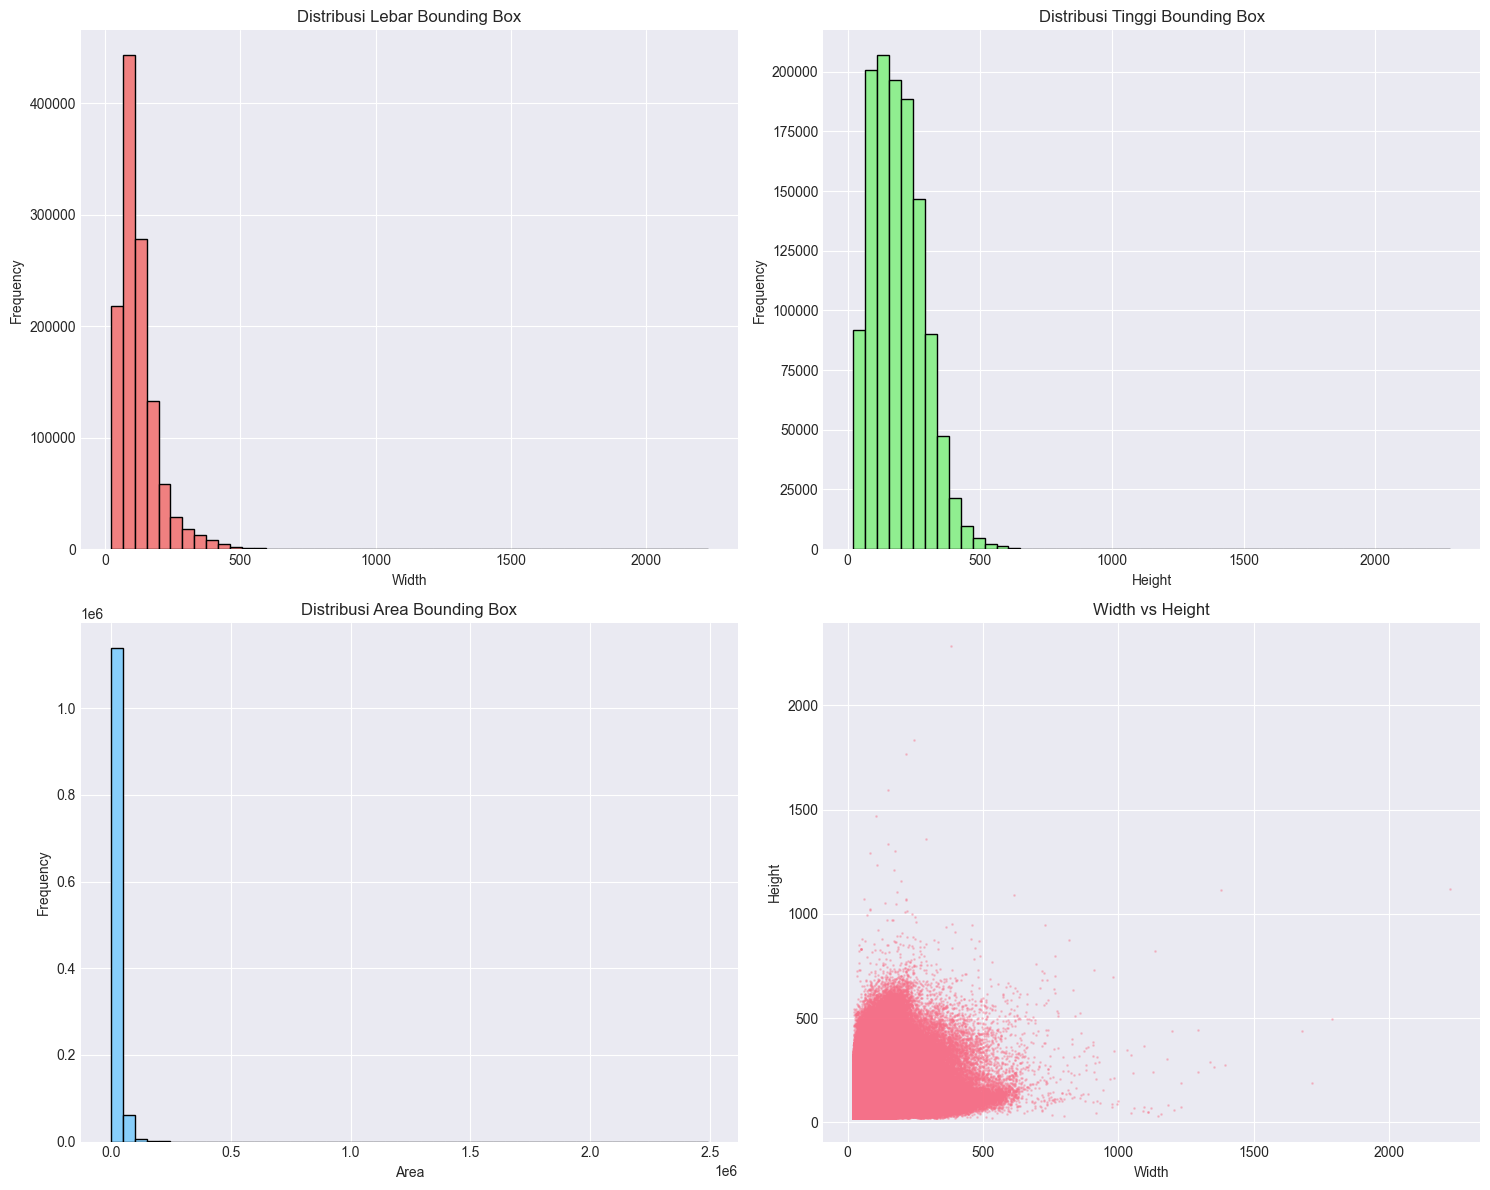

In [16]:
# Visualisasi ukuran bbox
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Width distribution
axes[0, 0].hist(train_df['bbox_width'], bins=50, color='lightcoral', edgecolor='black')
axes[0, 0].set_xlabel('Width')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribusi Lebar Bounding Box')

# Height distribution
axes[0, 1].hist(train_df['bbox_height'], bins=50, color='lightgreen', edgecolor='black')
axes[0, 1].set_xlabel('Height')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribusi Tinggi Bounding Box')

# Area distribution
axes[1, 0].hist(train_df['bbox_area'], bins=50, color='lightskyblue', edgecolor='black')
axes[1, 0].set_xlabel('Area')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribusi Area Bounding Box')

# Scatter: width vs height
axes[1, 1].scatter(train_df['bbox_width'], train_df['bbox_height'], alpha=0.3, s=1)
axes[1, 1].set_xlabel('Width')
axes[1, 1].set_ylabel('Height')
axes[1, 1].set_title('Width vs Height')

plt.tight_layout()
plt.show()

## 7. Visualisasi Sample Images

In [17]:
def visualize_image_with_boxes(image_name, df, split='train', figsize=(15, 10)):
    """
    Visualisasi image dengan bounding boxes
    Works with both flat and organized structure
    """
    # Determine image path based on structure
    if ORGANIZED_STRUCTURE:
        img_path = os.path.join(IMAGES_DIR, split, image_name)
    else:
        img_path = os.path.join(IMAGES_DIR, image_name)
    
    if not os.path.exists(img_path):
        print(f"⚠️ Image tidak ditemukan: {img_path}")
        return
    
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Get annotations untuk image ini
    img_boxes = df[df['image_name'] == image_name]
    
    # Draw bounding boxes
    for _, row in img_boxes.iterrows():
        x1, y1, x2, y2 = int(row['x1']), int(row['y1']), int(row['x2']), int(row['y2'])
        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
    
    # Plot
    plt.figure(figsize=figsize)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'{image_name}\nTotal Objects: {len(img_boxes)}', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    print(f"📦 Total objects detected: {len(img_boxes)}")
    print(f"📐 Image size: {img.shape[1]} x {img.shape[0]}")

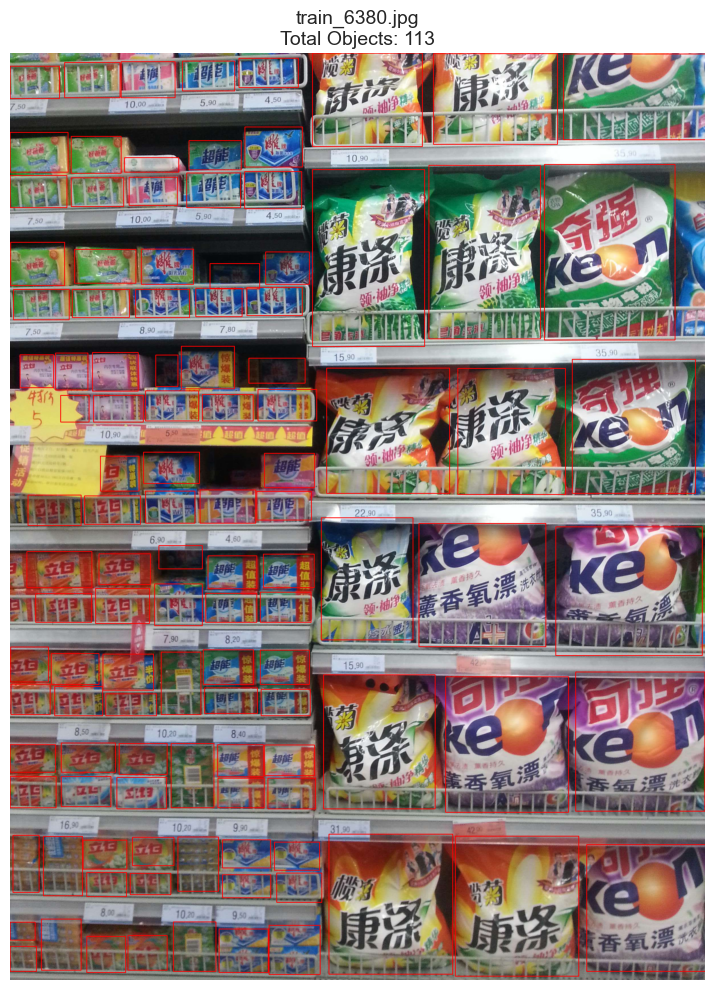

📦 Total objects detected: 113
📐 Image size: 2448 x 3264


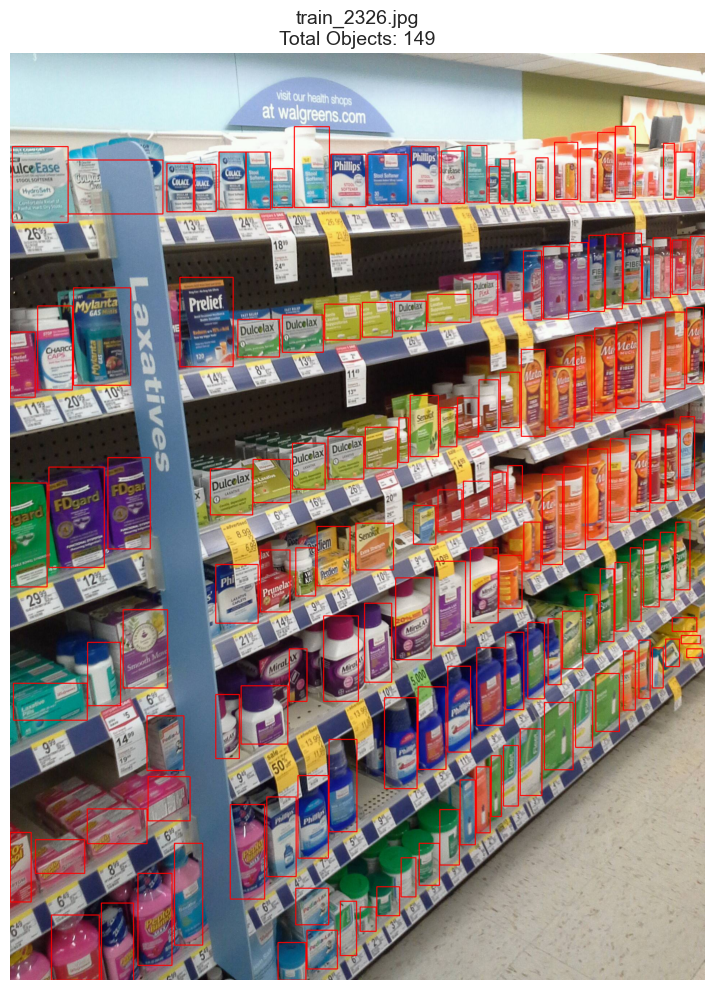

📦 Total objects detected: 149
📐 Image size: 1920 x 2560


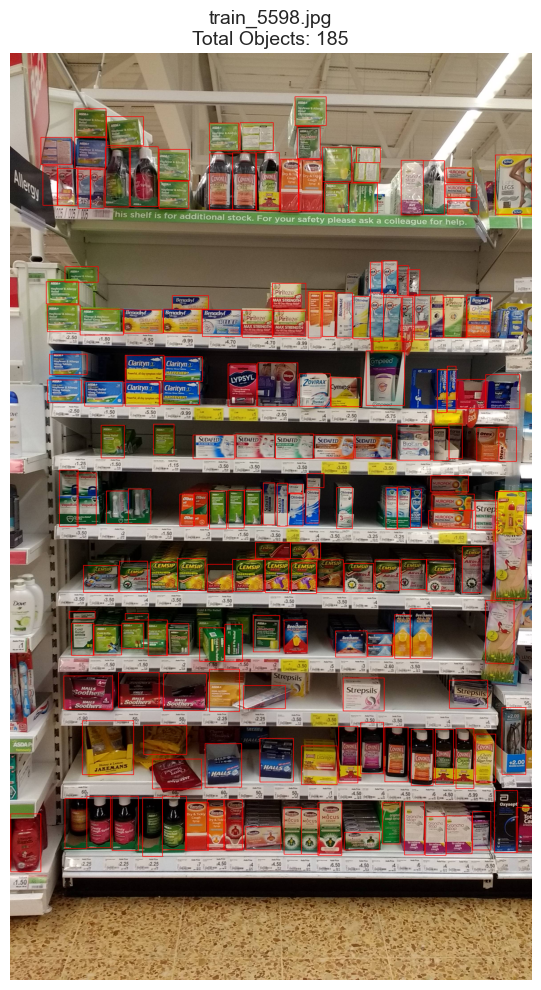

📦 Total objects detected: 185
📐 Image size: 2340 x 4160


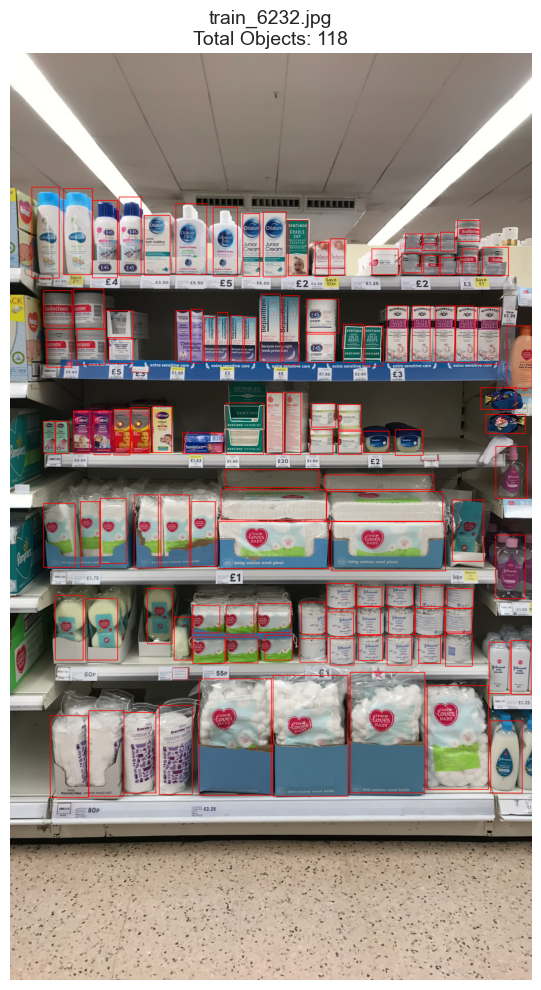

📦 Total objects detected: 118
📐 Image size: 2160 x 3840


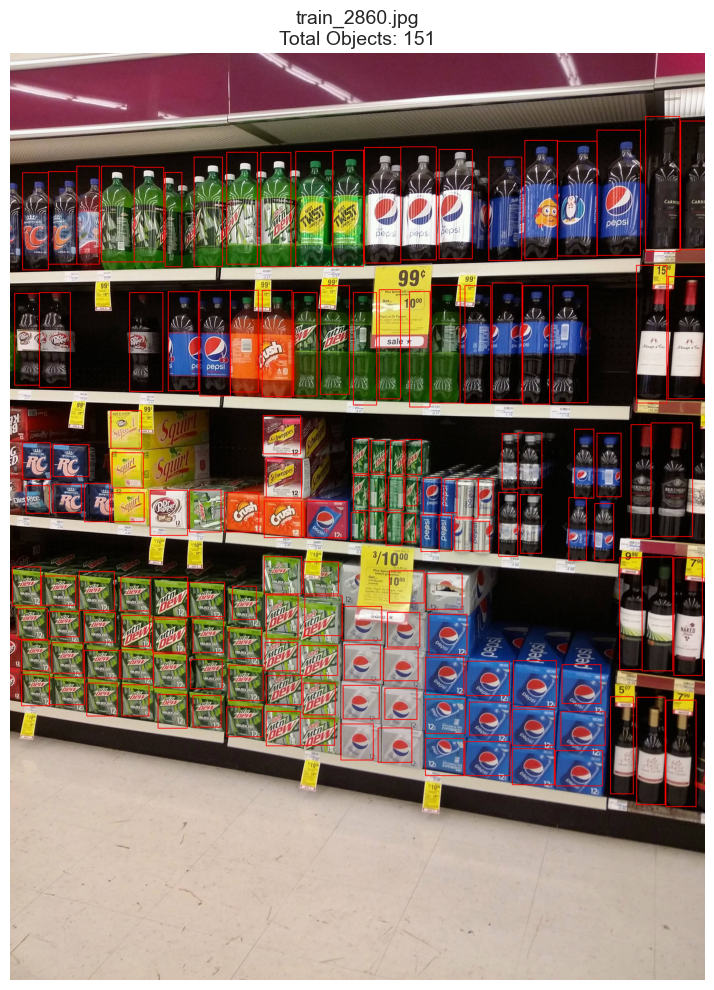

📦 Total objects detected: 151
📐 Image size: 2448 x 3264


In [18]:
# Visualisasi beberapa random samples
sample_images = objects_per_image.sample(5)['image_name'].values

for img_name in sample_images:
    visualize_image_with_boxes(img_name, train_df, split='train')

## 8. Analisis Kasus Khusus

📊 Image dengan objek terbanyak:
  • Nama: train_2619.jpg
  • Jumlah objek: 576


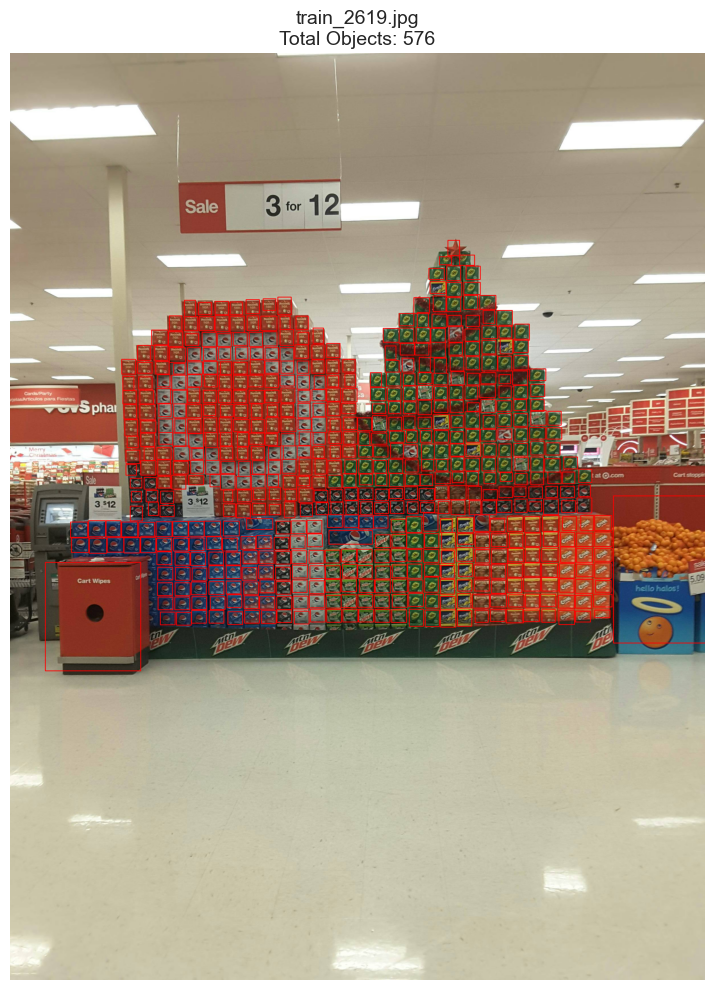

📦 Total objects detected: 576
📐 Image size: 2448 x 3264


In [19]:
# Image dengan objek paling banyak
max_objects_img = objects_per_image.loc[objects_per_image['count'].idxmax()]
print(f"📊 Image dengan objek terbanyak:")
print(f"  • Nama: {max_objects_img['image_name']}")
print(f"  • Jumlah objek: {max_objects_img['count']}")

visualize_image_with_boxes(max_objects_img['image_name'], train_df, split='train')

📊 Image dengan objek tersedikit:
  • Nama: train_3029.jpg
  • Jumlah objek: 1


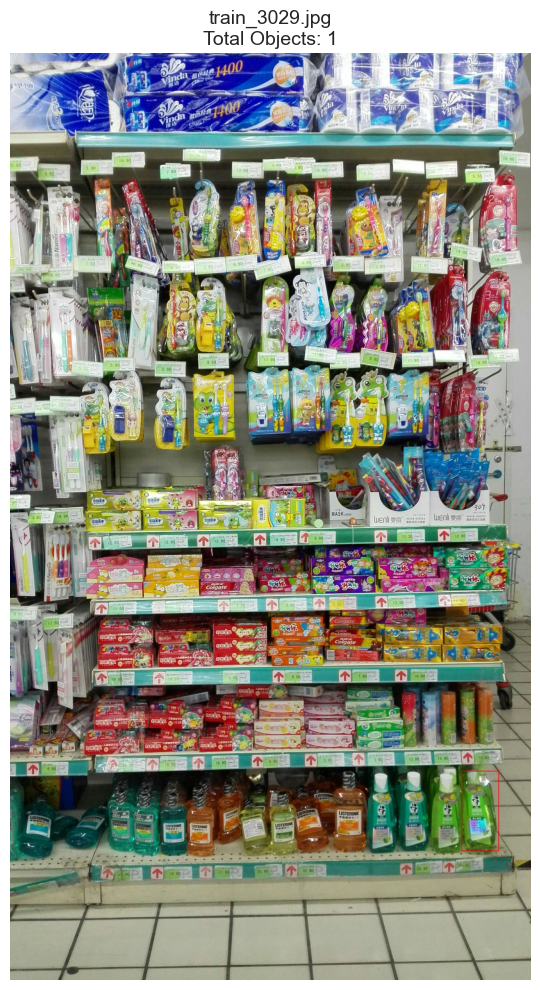

📦 Total objects detected: 1
📐 Image size: 2336 x 4160


In [20]:
# Image dengan objek paling sedikit
min_objects_img = objects_per_image.loc[objects_per_image['count'].idxmin()]
print(f"📊 Image dengan objek tersedikit:")
print(f"  • Nama: {min_objects_img['image_name']}")
print(f"  • Jumlah objek: {min_objects_img['count']}")

visualize_image_with_boxes(min_objects_img['image_name'], train_df, split='train')

## 9. Summary & Insights

In [21]:
print("="*70)
print("📊 DATASET SUMMARY")
print("="*70)

print(f"\n1. UKURAN DATASET:")
print(f"   • Total train images: {len(objects_per_image)}")
print(f"   • Total train annotations: {len(train_df)}")
print(f"   • Average objects per image: {objects_per_image['count'].mean():.2f}")

print(f"\n2. KARAKTERISTIK BOUNDING BOX:")
print(f"   • Average width: {train_df['bbox_width'].mean():.2f} pixels")
print(f"   • Average height: {train_df['bbox_height'].mean():.2f} pixels")
print(f"   • Average area: {train_df['bbox_area'].mean():.2f} pixels²")

print(f"\n3. INSIGHTS:")
print(f"   • Dataset sangat cocok untuk dense object detection")
print(f"   • Bounding boxes cenderung kecil (produk retail)")
print(f"   • Perlu model yang baik untuk handle objek kecil dan berdekatan")

print(f"\n4. REKOMENDASI:")
print(f"   • Gunakan YOLOv8 atau Faster R-CNN")
print(f"   • Input size: 640x640 atau lebih besar")
print(f"   • Augmentasi: rotation, flip, brightness untuk generalisasi")

print("\n" + "="*70)

📊 DATASET SUMMARY

1. UKURAN DATASET:
   • Total train images: 8219
   • Total train annotations: 1208482
   • Average objects per image: 147.04

2. KARAKTERISTIK BOUNDING BOX:
   • Average width: 120.81 pixels
   • Average height: 190.11 pixels
   • Average area: 22196.18 pixels²

3. INSIGHTS:
   • Dataset sangat cocok untuk dense object detection
   • Bounding boxes cenderung kecil (produk retail)
   • Perlu model yang baik untuk handle objek kecil dan berdekatan

4. REKOMENDASI:
   • Gunakan YOLOv8 atau Faster R-CNN
   • Input size: 640x640 atau lebih besar
   • Augmentasi: rotation, flip, brightness untuk generalisasi



## 10. Export Data Statistics

In [22]:
# Save statistics untuk referensi
stats = {
    'total_images': len(objects_per_image),
    'total_annotations': len(train_df),
    'avg_objects_per_image': objects_per_image['count'].mean(),
    'avg_bbox_width': train_df['bbox_width'].mean(),
    'avg_bbox_height': train_df['bbox_height'].mean(),
    'avg_bbox_area': train_df['bbox_area'].mean()
}

stats_df = pd.DataFrame([stats])
stats_df.to_csv('dataset_statistics.csv', index=False)
print("✓ Statistics saved to: dataset_statistics.csv")

✓ Statistics saved to: dataset_statistics.csv


## ✅ Next Steps:

1. **Preprocessing:** Resize images, normalize, augmentasi
2. **YOLOv8 Setup:** Convert format annotations ke YOLO
3. **Training:** Start training dengan pretrained model
4. **Evaluation:** Test pada validation set
5. **Integration:** Hubungkan dengan time series module